In [1]:
import os, json, math, random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

MANIFEST_PATH = "outputs_infer_v3/infer_v3_manifest.json"
OUT_DIR = "outputs_personas_v3"

os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

profiles = {}
for name, fname in manifest["profiles_files"].items():
    path = os.path.join(manifest["outputs_dir"], fname)
    profiles[name] = pd.read_parquet(path)

list(profiles.keys())


['threshold_18',
 'threshold_30',
 'threshold_50',
 'stratified',
 'distmatch',
 'influence_weighted']

In [3]:
def build_feature_space(df):
    X = pd.DataFrame({
        "opinion": df["rigidity"].astype(float),
        "activity": np.log1p(df["comments_per_day"].astype(float))
    })
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X


In [4]:
def fit_gmm(X, n_components=6):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=RANDOM_SEED
    )
    gmm.fit(Xs)

    probs = gmm.predict_proba(Xs)
    labels = probs.argmax(axis=1)

    return {
        "scaler": scaler,
        "gmm": gmm,
        "Xs": Xs,
        "probs": probs,
        "labels": labels
    }


In [5]:
gmm_outputs = {}

for name, df in profiles.items():
    X = build_feature_space(df)
    out = fit_gmm(X, n_components=6)

    df = df.copy()
    df["cluster"] = out["labels"]

    for k in range(out["probs"].shape[1]):
        df[f"cluster_p{k}"] = out["probs"][:, k]

    gmm_outputs[name] = {
        "profiles": df,
        "model": out
    }

gmm_outputs.keys()


dict_keys(['threshold_18', 'threshold_30', 'threshold_50', 'stratified', 'distmatch', 'influence_weighted'])

In [10]:
def sample_population(df, regime, n):
    if regime == "diverse":
        parts = []
        clusters = list(df["cluster"].unique())
        per = max(1, n // max(1, len(clusters)))

        for c in clusters:
            g = df[df["cluster"] == c]
            take = min(len(g), per)
            if take > 0:
                parts.append(g.sample(n=take, random_state=RANDOM_SEED))

        out = pd.concat(parts, axis=0) if parts else df.head(0)

        if len(out) < n and len(df) > len(out):
            need = min(n - len(out), len(df) - len(out))
            extra = df.drop(index=out.index, errors="ignore").sample(n=need, random_state=RANDOM_SEED)
            out = pd.concat([out, extra], axis=0)

        return out.sample(n=min(n, len(out)), random_state=RANDOM_SEED)

    if regime == "realistic":
        return df.sample(n=min(n, len(df)), random_state=RANDOM_SEED)

    if regime == "skewed":
        a = df["comments_per_day"].astype(float).rank(pct=True).to_numpy()
        r = df["rigidity"].astype(float).rank(pct=True).to_numpy()

        w = a * r
        w = np.where(np.isfinite(w), w, 0.0)

        w = w + 1e-12
        s = w.sum()
        if s <= 0:
            return df.sample(n=min(n, len(df)), random_state=RANDOM_SEED)

        w = w / s

        k = min(n, len(df))
        idx_pos = np.random.choice(np.arange(len(df)), size=k, replace=False, p=w)
        return df.iloc[idx_pos]

    raise ValueError(regime)


In [11]:
def persona_text(row):
    act = row["comments_per_day"]
    rig = row["rigidity"]

    if act < 0.5:
        activity = "rarely comments"
    elif act < 2:
        activity = "comments occasionally"
    else:
        activity = "comments frequently"

    if rig < 0.5:
        stance = "holds flexible views"
    elif rig < 2:
        stance = "has moderately strong views"
    else:
        stance = "holds strong, consistent views"

    return f"{activity} and {stance} on political topics."


In [12]:
def build_agent(row):
    return {
        "agent_id": row["author"],
        "persona": persona_text(row),
        "state": {
            "belief_vector": [
                float(row["rigidity"]),
                float(np.log1p(row["comments_per_day"]))
            ],
            "cluster": int(row["cluster"]),
            "cluster_probs": [
                float(row[f"cluster_p{k}"])
                for k in range(6)
            ]
        },
        "behavior": {
            "comments_per_day": float(row["comments_per_day"]),
            "avg_comment_length": float(row["avg_length"]),
            "sentiment_mean": float(row["avg_sentiment"])
        }
    }

In [13]:
POP_SIZE = 2000
POP_REGIMES = ["diverse", "realistic", "skewed"]

for sample_name, pack in gmm_outputs.items():
    df = pack["profiles"]

    for pop in POP_REGIMES:
        samp = sample_population(df, pop, POP_SIZE)

        agents = [build_agent(r) for _, r in samp.iterrows()]

        out_path = os.path.join(
            OUT_DIR,
            f"agents_{sample_name}_{pop}.json"
        )

        with open(out_path, "w") as f:
            json.dump(agents, f, indent=2)

        print(f"wrote {out_path} ({len(agents)} agents)")

wrote outputs_personas_v3/agents_threshold_18_diverse.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_18_realistic.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_18_skewed.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_30_diverse.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_30_realistic.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_30_skewed.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_50_diverse.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_50_realistic.json (2000 agents)
wrote outputs_personas_v3/agents_threshold_50_skewed.json (2000 agents)
wrote outputs_personas_v3/agents_stratified_diverse.json (2000 agents)
wrote outputs_personas_v3/agents_stratified_realistic.json (2000 agents)
wrote outputs_personas_v3/agents_stratified_skewed.json (2000 agents)
wrote outputs_personas_v3/agents_distmatch_diverse.json (2000 agents)
wrote outputs_personas_v3/agents_distmatch_realistic.jso

In [14]:
meta = {}

for name, pack in gmm_outputs.items():
    gmm = pack["model"]["gmm"]
    meta[name] = {
        "weights": gmm.weights_.tolist(),
        "means": gmm.means_.tolist(),
        "covariances": gmm.covariances_.tolist()
    }

meta_path = os.path.join(OUT_DIR, "gmm_metadata.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

meta_path

'outputs_personas_v3/gmm_metadata.json'

In [25]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

In [26]:
OUT_DIR = "outputs_personas_v3"
persona_paths = sorted(glob.glob(os.path.join(OUT_DIR, "agents_*.json")))
assert len(persona_paths) > 0, "No persona json files found."

def load_agents(path):
    with open(path, "r") as f:
        agents = json.load(f)
    df = pd.json_normalize(agents)
    df["__file__"] = os.path.basename(path)
    return df

dfs = [load_agents(p) for p in persona_paths]
agents_all = pd.concat(dfs, axis=0, ignore_index=True)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

COL_PERSONA = pick_col(agents_all, ["persona"])
COL_ID = pick_col(agents_all, ["agent_id"])
COL_CPD = pick_col(agents_all, ["behavior.comments_per_day"])
COL_LEN = pick_col(agents_all, ["behavior.avg_comment_length"])
COL_SENT = pick_col(agents_all, ["behavior.sentiment_mean"])
COL_CLUSTER = pick_col(agents_all, ["state.cluster"])

COL_BELIEF0 = pick_col(agents_all, ["state.belief_vector.0"])
COL_BELIEF1 = pick_col(agents_all, ["state.belief_vector.1"])

for c in [COL_CPD, COL_LEN, COL_SENT, COL_BELIEF0, COL_BELIEF1, COL_CLUSTER]:
    if c is not None:
        agents_all[c] = pd.to_numeric(agents_all[c], errors="coerce")

agents_all.head(2)

,agent_id,persona,state.belief_vector,state.cluster,state.cluster_probs,behavior.comments_per_day,behavior.avg_comment_length,behavior.sentiment_mean,__file__
0,thiefzer0,"comments frequently and holds strong, consiste...","[3.179027577014151, 1.0986122886681098]",5,"[8.0305256465017e-29, 0.0, 0.0, 2.037991238825...",2.000000,183.5,0.62245,agents_distmatch_diverse.json
1,maiky38,"comments occasionally and holds strong, consis...","[7.790349545837514, 1.0146388372539905]",5,"[9.013682087908761e-200, 0.0, 0.0, 0.0, 1.2954...",1.758367,319.0,-0.82685,agents_distmatch_diverse.json


In [28]:
def dup_rate_by_file(df, col):
    if col is None or col not in df.columns:
        return None
    g = df.groupby("__file__")[col].agg(["size", "nunique"]).reset_index()
    g["dup_rate"] = 1.0 - (g["nunique"] / g["size"])
    return g.sort_values("dup_rate", ascending=False)

def vector_signature(df):
    cols = [c for c in [COL_BELIEF0, COL_BELIEF1, COL_CPD, COL_LEN, COL_SENT, COL_CLUSTER] if c is not None]
    sig = df[cols].round(6).astype(str).agg("|".join, axis=1)
    return sig

agents_all["__vec_sig__"] = vector_signature(agents_all)

dup_persona = dup_rate_by_file(agents_all, COL_PERSONA)
dup_vecsig = dup_rate_by_file(agents_all, "__vec_sig__")

print("Persona text duplication (expected high with templates):")
display(dup_persona)

print("State/behavior vector signature duplication:")
display(dup_vecsig)

Persona text duplication (expected high with templates):


,__file__,size,nunique,dup_rate
16,agents_threshold_50_realistic.json,2000,6,0.9970
13,agents_threshold_30_realistic.json,2000,7,0.9965
17,agents_threshold_50_skewed.json,2000,7,0.9965
15,agents_threshold_50_diverse.json,2000,7,0.9965
10,agents_threshold_18_realistic.json,2000,7,0.9965
9,agents_threshold_18_diverse.json,2000,8,0.9960
14,agents_threshold_30_skewed.json,2000,8,0.9960
12,agents_threshold_30_diverse.json,2000,8,0.9960
11,agents_threshold_18_skewed.json,2000,8,0.9960
0,agents_distmatch_diverse.json,2000,9,0.9955


State/behavior vector signature duplication:


,__file__,size,nunique,dup_rate
7,agents_stratified_realistic.json,2000,1777,0.1115
6,agents_stratified_diverse.json,2000,1782,0.1090
3,agents_influence_weighted_diverse.json,2000,1789,0.1055
4,agents_influence_weighted_realistic.json,2000,1885,0.0575
8,agents_stratified_skewed.json,2000,1963,0.0185
5,agents_influence_weighted_skewed.json,2000,1977,0.0115
0,agents_distmatch_diverse.json,2000,1988,0.0060
1,agents_distmatch_realistic.json,2000,1992,0.0040
2,agents_distmatch_skewed.json,2000,1999,0.0005
9,agents_threshold_18_diverse.json,2000,2000,0.0000


In [29]:
def top_repeated_text(df, file_name, col, k=10):
    if col is None:
        return None
    sub = df[df["__file__"] == file_name]
    vc = sub[col].fillna("").value_counts()
    out = vc.head(k).reset_index()
    out.columns = [col, "count"]
    return out

if COL_PERSONA is not None:
    for f in sorted(agents_all["__file__"].unique())[:6]:
        print("\nFILE:", f)
        display(top_repeated_text(agents_all, f, COL_PERSONA, k=8))


FILE: agents_distmatch_diverse.json


,persona,count
0,comments frequently and has moderately strong ...,565
1,comments frequently and holds flexible views o...,384
2,"comments occasionally and holds strong, consis...",268
3,rarely comments and holds flexible views on po...,241
4,rarely comments and has moderately strong view...,200
5,"comments frequently and holds strong, consiste...",148
6,"rarely comments and holds strong, consistent v...",82
7,comments occasionally and holds flexible views...,81



FILE: agents_distmatch_realistic.json


,persona,count
0,rarely comments and holds flexible views on po...,777
1,rarely comments and has moderately strong view...,403
2,comments frequently and has moderately strong ...,302
3,comments frequently and holds flexible views o...,294
4,"comments occasionally and holds strong, consis...",78
5,comments occasionally and holds flexible views...,75
6,"comments frequently and holds strong, consiste...",38
7,comments occasionally and has moderately stron...,19



FILE: agents_distmatch_skewed.json


...

,persona,count
0,comments occasionally and holds flexible views...,353
1,"comments occasionally and holds strong, consis...",343
2,rarely comments and holds flexible views on po...,323
3,"comments frequently and holds strong, consiste...",252
4,rarely comments and has moderately strong view...,243
5,"rarely comments and holds strong, consistent v...",209
6,comments frequently and has moderately strong ...,152
7,comments frequently and holds flexible views o...,111



FILE: agents_influence_weighted_realistic.json


,persona,count
0,"comments occasionally and holds strong, consis...",663
1,rarely comments and holds flexible views on po...,548
2,comments occasionally and holds flexible views...,226
3,rarely comments and has moderately strong view...,222
4,comments frequently and holds flexible views o...,126
5,comments frequently and has moderately strong ...,120
6,"rarely comments and holds strong, consistent v...",48
7,"comments frequently and holds strong, consiste...",40



FILE: agents_influence_weighted_skewed.json


,persona,count
0,"comments occasionally and holds strong, consis...",1266
1,comments frequently and has moderately strong ...,216
2,"comments frequently and holds strong, consiste...",114
3,comments frequently and holds flexible views o...,111
4,rarely comments and holds flexible views on po...,108
5,rarely comments and has moderately strong view...,88
6,comments occasionally and holds flexible views...,53
7,"rarely comments and holds strong, consistent v...",30


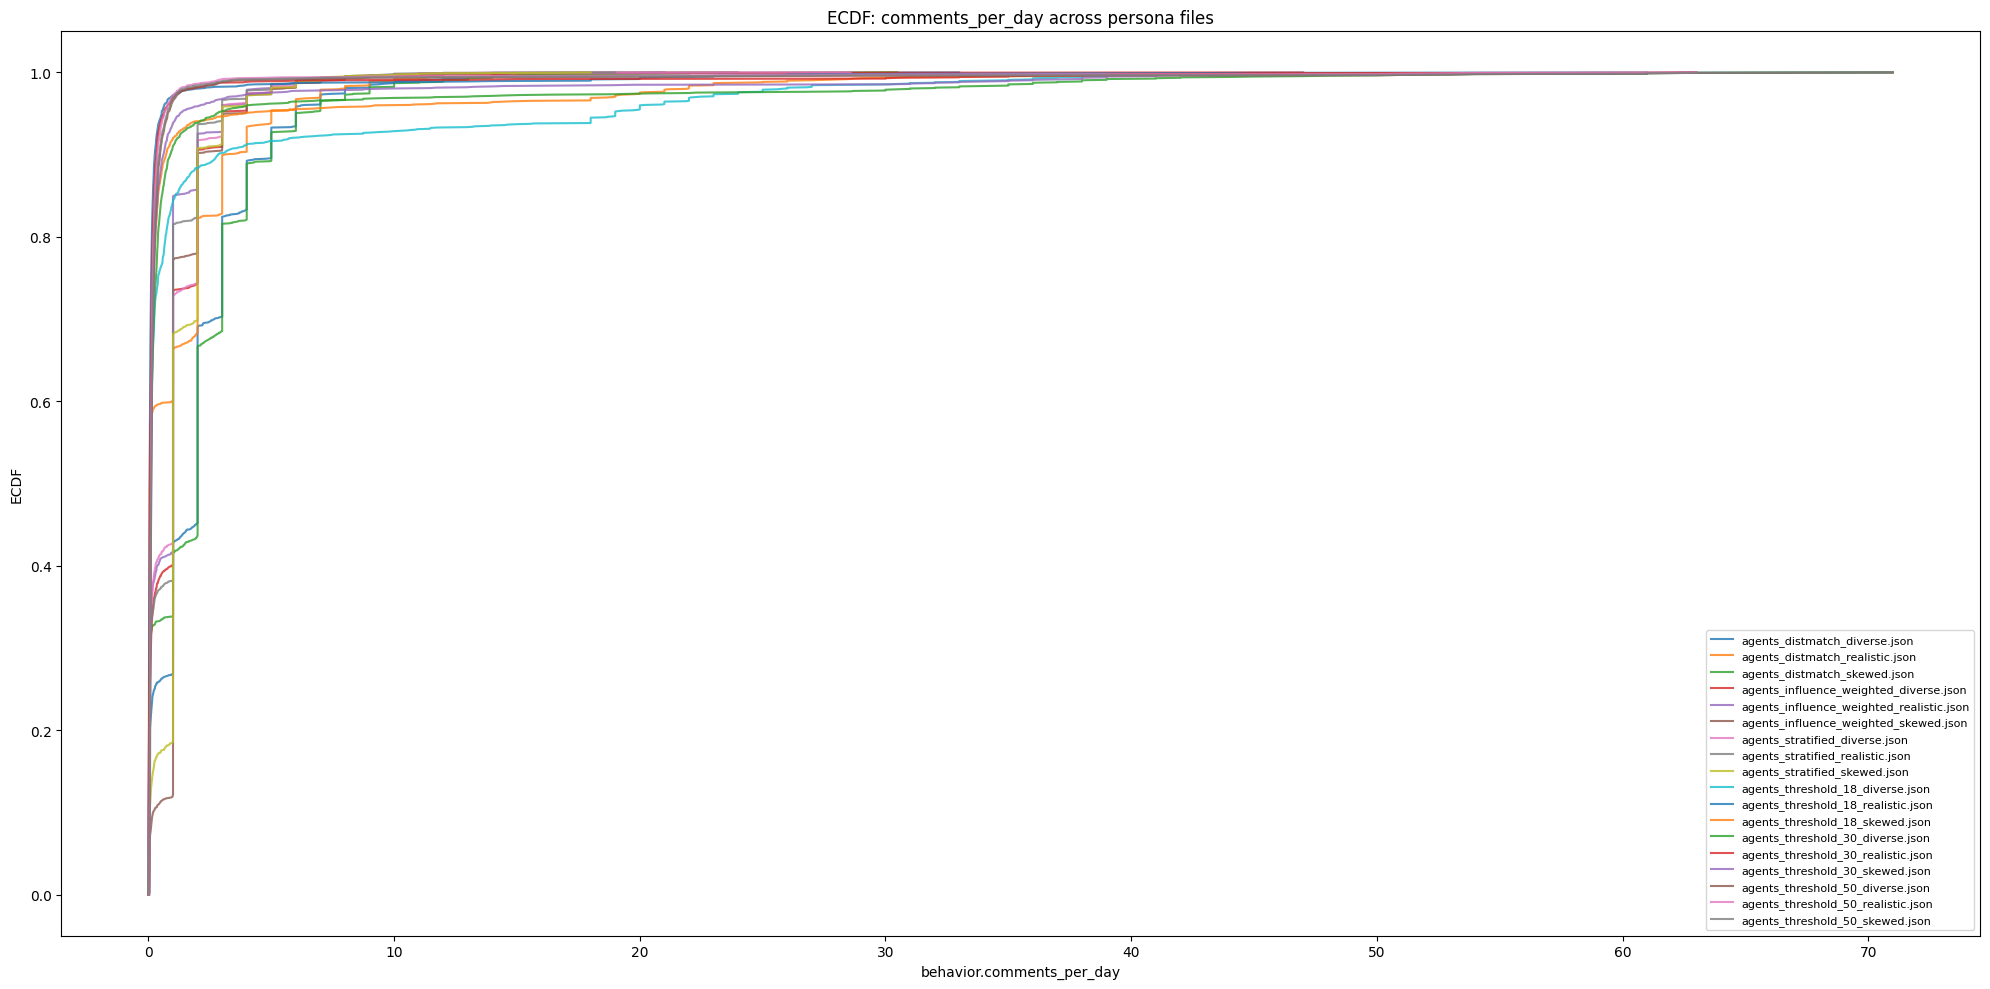

In [32]:
def plot_ecdf_by_file(df, col, title):
    if col is None:
        return
    plt.figure(figsize=(20, 10))
    for f, sub in df.groupby("__file__"):
        x = sub[col].dropna().values
        if len(x) < 20:
            continue
        x = np.sort(x)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.plot(x, y, alpha=0.8, label=f)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("ECDF")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_ecdf_by_file(agents_all, COL_CPD, "ECDF: comments_per_day across persona files")
plot_ecdf_by_file(agents_all, COL_BELIEF0, "ECDF: belief_vector[0] (rigidity proxy) across persona files")
plot_ecdf_by_file(agents_all, COL_BELIEF1, "ECDF: belief_vector[1] (log activity) across persona files")

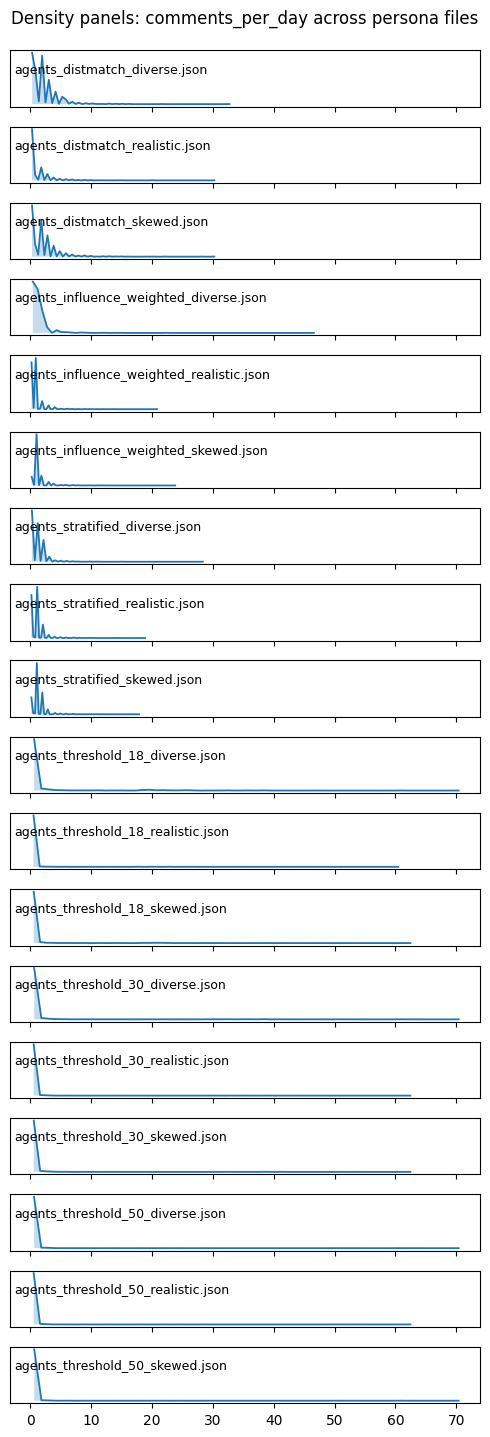

In [34]:
def plot_density_panels(df, col, title, bins=60, max_files=18):
    if col is None:
        return
    files = sorted(df["__file__"].unique())[:max_files]
    fig, axes = plt.subplots(len(files), 1, figsize=(5, 0.8 * len(files)), sharex=True)
    if len(files) == 1:
        axes = [axes]

    for ax, f in zip(axes, files):
        x = df.loc[df["__file__"] == f, col].dropna().values
        if len(x) < 10:
            ax.text(0.01, 0.3, f"{f} (no data)", transform=ax.transAxes)
            ax.set_yticks([])
            continue

        h, edges = np.histogram(x, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, h, linewidth=1.3)
        ax.fill_between(centers, 0, h, alpha=0.25)
        ax.text(0.01, 0.6, f, transform=ax.transAxes, fontsize=9)
        ax.set_yticks([])

    fig.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()

plot_density_panels(agents_all, COL_CPD, "Density panels: comments_per_day across persona files")
plot_density_panels(agents_all, COL_BELIEF0, "Density panels: belief_vector[0] across persona files")

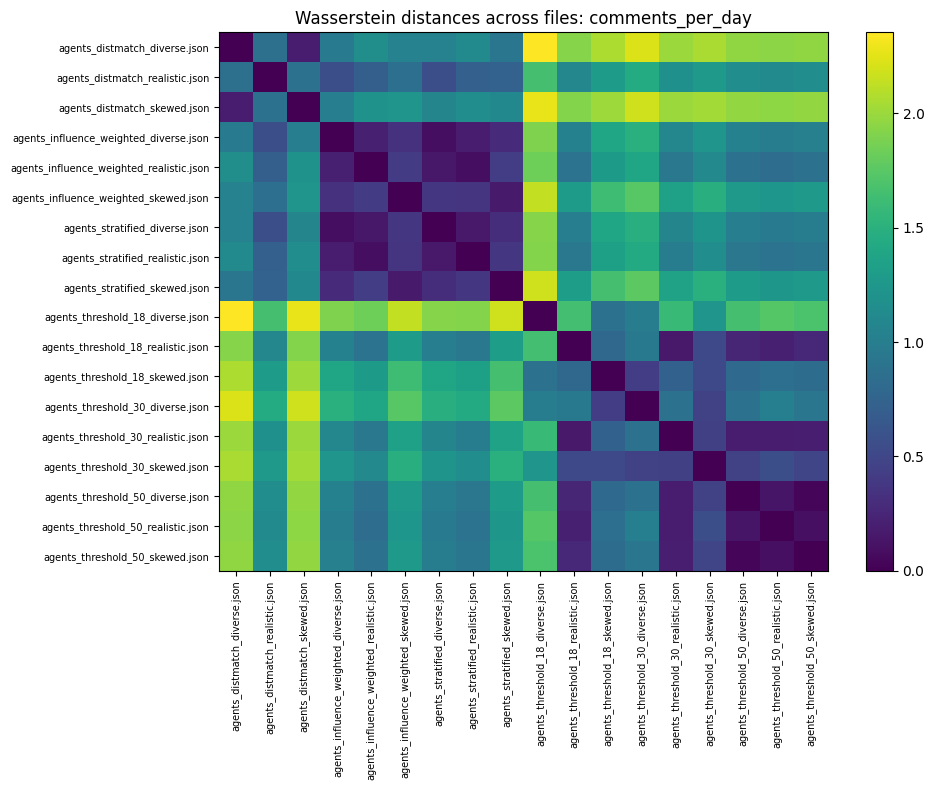

In [35]:
from scipy.stats import wasserstein_distance

def file_distance_matrix(df, col):
    files = sorted(df["__file__"].unique())
    mat = np.zeros((len(files), len(files)), dtype=float)
    for i, fi in enumerate(files):
        xi = df.loc[df["__file__"] == fi, col].dropna().values
        for j, fj in enumerate(files):
            xj = df.loc[df["__file__"] == fj, col].dropna().values
            if len(xi) < 5 or len(xj) < 5:
                mat[i, j] = np.nan
            else:
                mat[i, j] = float(wasserstein_distance(xi, xj))
    return files, mat

def plot_heatmap(files, mat, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(files)), files, rotation=90, fontsize=7)
    plt.yticks(range(len(files)), files, fontsize=7)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for col, title in [
    (COL_CPD, "Wasserstein distances across files: comments_per_day"),
    (COL_BELIEF0, "Wasserstein distances across files: belief_vector[0]"),
]:
    if col is not None:
        files, mat = file_distance_matrix(agents_all, col)
        plot_heatmap(files, mat, title)

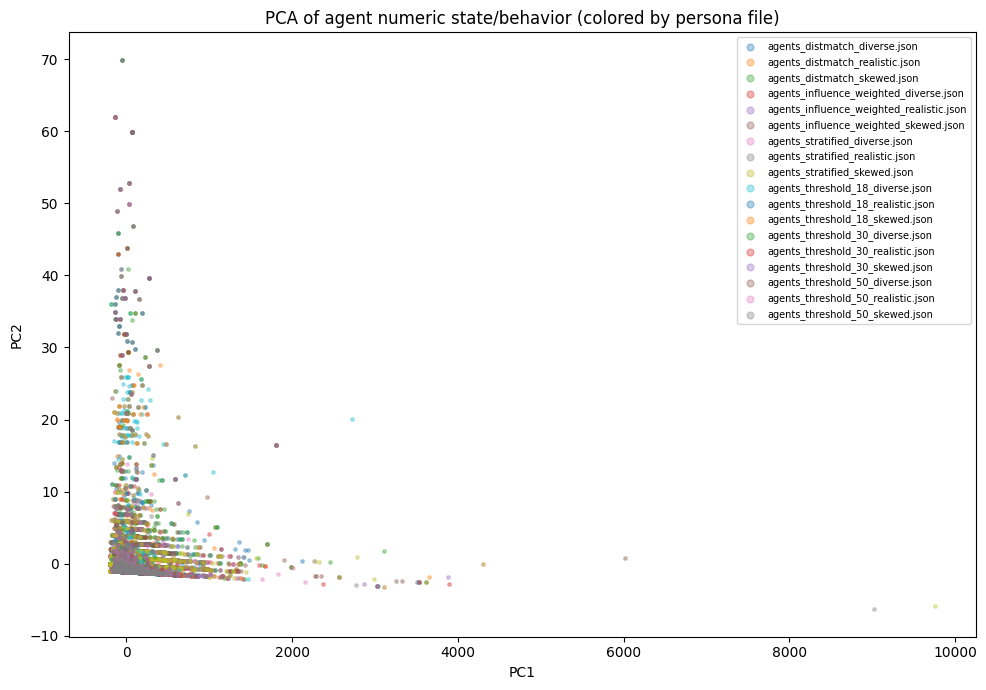

In [38]:
cols = [c for c in [COL_BELIEF0, COL_BELIEF1, COL_CPD, COL_LEN, COL_SENT] if c is not None]
X = agents_all[cols].copy().fillna(0.0).to_numpy(dtype=float)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
for f, sub_idx in agents_all.groupby("__file__").indices.items():
    pts = Z[sub_idx]
    plt.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label=f)

plt.title("PCA of agent numeric state/behavior (colored by persona file)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=7, markerscale=2, loc="best")
plt.tight_layout()
plt.show()


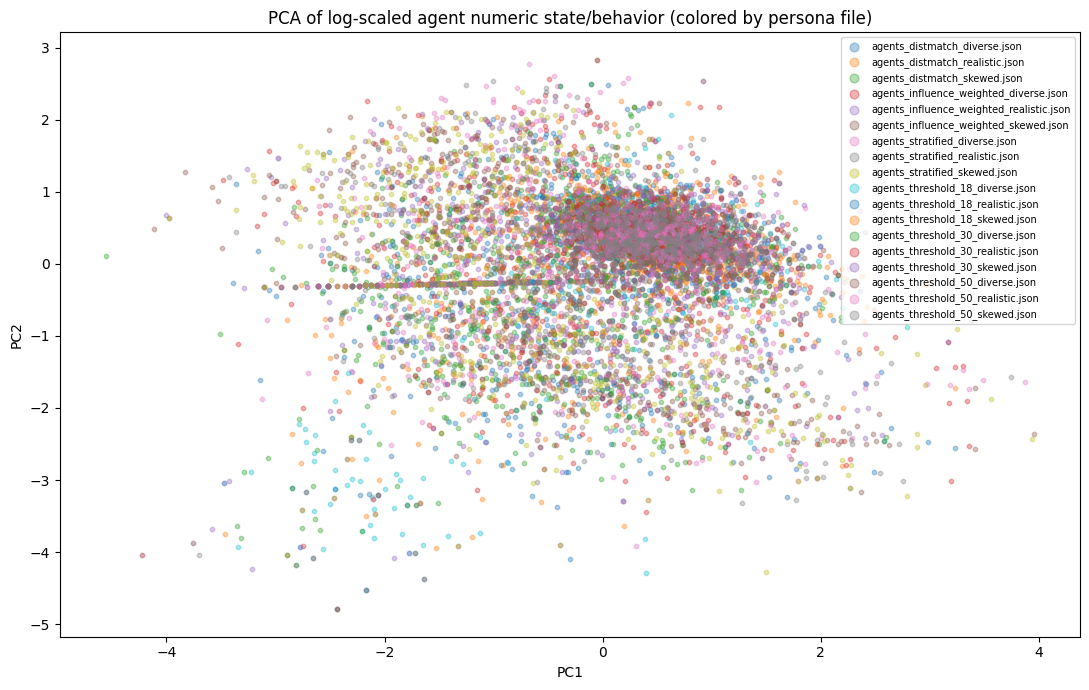

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cols = [c for c in [COL_BELIEF0, COL_BELIEF1, COL_CPD, COL_LEN, COL_SENT] if c is not None]
X = agents_all[cols].copy().fillna(0.0)

log_cols = [c for c in [COL_CPD, COL_LEN] if c is not None]
for c in log_cols:
    X[c] = np.log1p(np.clip(X[c].astype(float).values, a_min=0.0, a_max=None))

scaler = StandardScaler()
Xs = scaler.fit_transform(X.to_numpy(dtype=float))

pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(Xs)

file_counts = agents_all["__file__"].value_counts()
top_files = file_counts.index.tolist()

plt.figure(figsize=(11, 7))

for f in top_files:
    idx = agents_all.index[agents_all["__file__"] == f].to_numpy()
    if len(idx) == 0:
        continue
    if len(idx) > 600:
        idx = np.random.RandomState(RANDOM_SEED).choice(idx, size=600, replace=False)

    pts = Z[idx]
    plt.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.35, label=f)

plt.title("PCA of log-scaled agent numeric state/behavior (colored by persona file)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=7, markerscale=2, loc="best")
plt.tight_layout()
plt.show()
